# Tatoeba: N-Gram Hashing

Author: Pierre Nugues


In this notbook, we will reduce the size of the n-gram vectors using hashing techniques

This is a preliminary step to understand language detection and CLD3, https://github.com/google/cld3


In [2]:
import random
from collections import Counter
import torch
import matplotlib.pyplot as plt

In [3]:
random.seed(4321)
torch.manual_seed(4321)

## Reading the Dataset


In [4]:
FILE = 'sentences.csv'

Adjust your path


In [5]:
SMALL_DATASET_PATH = '.'
LARGE_DATASET_PATH = '.'

In [6]:
SMALL = False

In [7]:
if SMALL:
    dataset_path = SMALL_DATASET_PATH
else:
    dataset_path = LARGE_DATASET_PATH
    
WORKING_FILE = dataset_path + '/' + FILE

We create a generator


In [8]:
def file_reader(file):
    with open(file, encoding='utf8', errors='ignore') as f:
        for line in f:
            row = line.strip()
            yield tuple(row.split('\t'))

In [9]:
line_generator = file_reader(WORKING_FILE)

And we count the sentences per language


In [10]:
lang_freqs = Counter(map(lambda x: x[1], line_generator))

In [11]:
lang_freqs.most_common(15)

[('eng', 1994102),
 ('rus', 1156129),
 ('ita', 944469),
 ('epo', 798465),
 ('kab', 772984),
 ('tur', 740628),
 ('deu', 736378),
 ('ber', 693672),
 ('fra', 688340),
 ('por', 438056),
 ('hun', 422909),
 ('spa', 421384),
 ('jpn', 246597),
 ('heb', 209894),
 ('nld', 194094)]

In [12]:
langs = sorted(list(set(lang_freqs.keys())))
langs[:10]

['\\N', 'abk', 'abq', 'acm', 'ady', 'afb', 'afh', 'afr', 'aii', 'ain']

## Extracting n-grams


In [13]:
def ngrams(sentence, n=1, lc=True):
    ngram_l = []
    if lc:
        sentence = sentence.lower()
    for i in range(len(sentence) - n + 1):
        ngram_l += [sentence[i:i+n]]
    return ngram_l

In [14]:
def all_ngrams(sentence, max_ngram=3, lc=True):
    all_ngram_list = []
    for i in range(1, max_ngram + 1):
        all_ngram_list += [ngrams(sentence, n=i, lc=lc)]
    return all_ngram_list

In [15]:
all_ngrams('banana')

[['b', 'a', 'n', 'a', 'n', 'a'],
 ['ba', 'an', 'na', 'an', 'na'],
 ['ban', 'ana', 'nan', 'ana']]

## Extracting n-grams from the corpus


In [16]:
def extract_ngrams():
    with open(WORKING_FILE, encoding='utf8', errors='ignore') as f:
        for line in f:
            row = line.strip()
            lang_tuple = tuple(row.split('\t'))
            lang = lang_tuple[1]
            if lang in langs:
                yield all_ngrams(lang_tuple[2])       

We assume three, otherwise we have to create a list


In [17]:
charset = set()
bigram_set = set()
trigram_set = set()

In [18]:
for triple in extract_ngrams():
    charset.update(triple[0])
    bigram_set.update(triple[1])
    trigram_set.update(triple[2])


In [19]:
len(charset), len(bigram_set), len(trigram_set)

(11404, 510119, 2201377)

## Hashing the n-grams and limiting their numbers


In [20]:
hash('ads'), hash('ads') % 100

(-8428638960169018601, 99)

In [21]:
if SMALL:
    MAX_CHARS = 521
    MAX_BIGRAMS = 1031
    MAX_TRIGRAMS = 1031  
else:
    MAX_CHARS = 2053
    MAX_BIGRAMS = 4099
    MAX_TRIGRAMS = 4099  #8192

In [22]:
NUM_FEATURES = MAX_CHARS + MAX_BIGRAMS + MAX_TRIGRAMS
NUM_FEATURES

10251

In [23]:
def hash_conflicts(symbol_set, modulo):
    conflict_dict = dict()
    for symb in symbol_set:
        hash_code = hash(symb) % modulo
        if hash_code in conflict_dict:
            conflict_dict[hash_code] += [symb]
        else:
            conflict_dict[hash_code] = [symb]
    return conflict_dict

In [24]:
hash_conflicts_1 = hash_conflicts(charset, MAX_CHARS)
hash_conflicts_2 = hash_conflicts(bigram_set, MAX_BIGRAMS)
hash_conflicts_3 = hash_conflicts(trigram_set, MAX_TRIGRAMS)

In [25]:
hash('a') % 2053

1379

In [26]:
hash_conflicts_1[1308]

['ف', '晃', 'ꠁ', 'ﬞ', 'ൺ', '拒']

In [27]:
hash('abc') % 4099

2591

In [28]:
hash_conflicts_3[672]

['uwc',
 '窮人同',
 'bēs',
 'ラー映',
 ' *e',
 '。入る',
 'けかあ',
 '業績拡',
 'æлт',
 '眼睛了',
 '之后变',
 'amö',
 '想跟一',
 '、礼を',
 'もしマ',
 'нья',
 '子陪伴',
 '独醒。',
 '小人一',
 '核武庫',
 'し全損',
 '乗りが',
 '條柱嘅',
 '義就會',
 '個交叉',
 '心而係',
 '蒂帕再',
 '各人が',
 '晨6点',
 '了回來',
 'ብሸል',
 '東歐群',
 'ेलत',
 'qeṣ',
 '誌非常',
 '踩落去',
 '家嘅夜',
 '錢去幫',
 'đãi',
 'đeo',
 'いたダ',
 '而向內',
 'んに座',
 '歷鼻！',
 '咗責任',
 'τιό',
 '害吗？',
 '? л',
 'f1有',
 '課上什',
 'して顧',
 'ејц',
 '我睇到',
 'িৰ-',
 '引起共',
 '佢件雨',
 '了我膝',
 '語の雰',
 'す人は',
 'వ ప',
 '吞咗。',
 'ɣmu',
 'て兜の',
 'た時よ',
 '文理，',
 '日嗰個',
 '同埋莫',
 '수감되',
 '姆把椅',
 '兩手各',
 ' ተኣ',
 '他道歉',
 '時嚟開',
 'ففم',
 '已，不',
 '頭亞馬',
 'ほー。',
 '話你愛',
 'すぐ行',
 '個天一',
 '晩彼の',
 'とじゃ',
 '制定呢',
 '基地に',
 '揸車呀',
 '妈不是',
 '期待薄',
 'ｐｒ．',
 '野豬等',
 '瓶水吗',
 '敗嘅恐',
 '台持っ',
 'чье',
 'ōpæ',
 '是告訴',
 '贺他俩',
 '心なし',
 '在五分',
 '̧ 1',
 '«كې',
 '蠢嘅實',
 '達は山',
 '用對車',
 'とがナ',
 'うずら',
 'っこぺ',
 '上玩遊',
 '張でパ',
 'て犬が',
 'gel',
 '快嗰一',
 'ኒ፣እ',
 'īx?',
 '怕的那',
 '立校よ',
 '情要跟',
 '履歷給',
 '着き、',
 '斯黑手',
 '門關了',
 '那我先',
 '服買っ',
 '她这礼',
 '1まで',
 'ると料',


Expected number of symbols per hash code


In [29]:
len(charset)/MAX_CHARS, len(bigram_set)/MAX_BIGRAMS, len(trigram_set)/MAX_TRIGRAMS

(5.554797856794934, 124.44962185899, 537.0522078555746)

Observed frequencies


In [30]:
cnt_hc_1 = Counter(map(len, hash_conflicts_1.values()))
cnt_hc_1

Counter({4: 337,
         5: 326,
         6: 317,
         7: 254,
         3: 219,
         8: 180,
         2: 123,
         9: 107,
         10: 74,
         1: 53,
         11: 31,
         12: 13,
         13: 6,
         14: 4,
         16: 1})

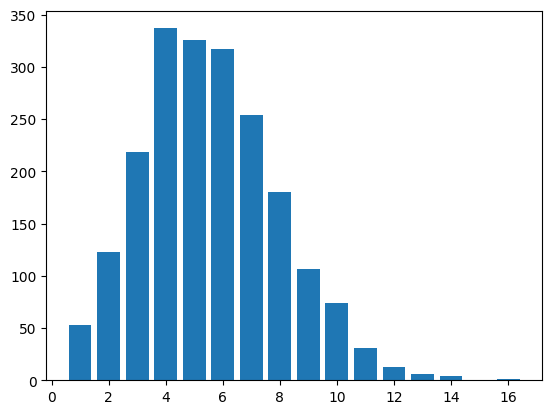

In [31]:
plt.bar(cnt_hc_1.keys(), cnt_hc_1.values())
plt.show()

In [32]:
cnt_hc_2= Counter(map(len, hash_conflicts_2.values()))
cnt_hc_2

Counter({125: 151,
         123: 149,
         128: 148,
         126: 142,
         119: 142,
         130: 140,
         120: 138,
         127: 133,
         118: 133,
         124: 132,
         121: 129,
         117: 125,
         132: 122,
         129: 118,
         122: 114,
         131: 111,
         113: 107,
         135: 103,
         114: 102,
         116: 102,
         115: 101,
         133: 100,
         136: 98,
         134: 88,
         112: 78,
         111: 77,
         138: 74,
         137: 69,
         109: 67,
         110: 63,
         141: 57,
         108: 54,
         140: 54,
         139: 51,
         107: 49,
         142: 44,
         146: 34,
         144: 34,
         143: 33,
         105: 33,
         145: 33,
         106: 31,
         104: 26,
         102: 25,
         101: 23,
         103: 18,
         147: 15,
         152: 15,
         148: 13,
         149: 12,
         99: 11,
         100: 11,
         151: 10,
         154: 8,
        

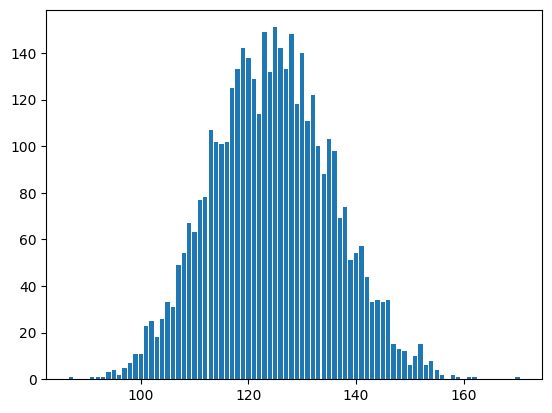

In [33]:
plt.bar(cnt_hc_2.keys(), cnt_hc_2.values())
plt.show()

In [34]:
cnt_hc_3 = Counter(map(len, hash_conflicts_3.values()))

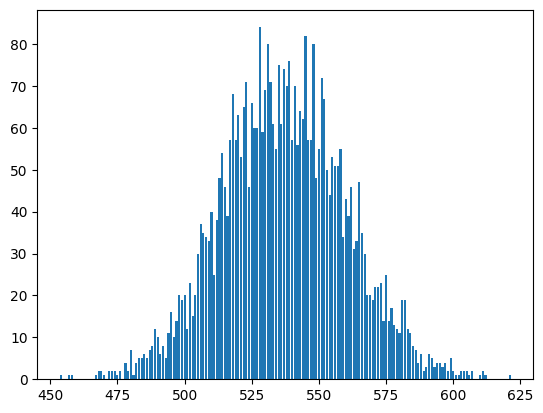

In [35]:
plt.bar(cnt_hc_3.keys(), cnt_hc_3.values())
plt.show()